# 07b — Eksperimen XGBoost & Skema Ensemble


In [ ]:
import sys

import os
import json

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import optuna

os.makedirs("../models", exist_ok=True)


c:\Users\Yosua Triantara\miniconda3\envs\foodseg\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load sequence features + prediksi LSTM terbaik (dari `06b`)

In [2]:
data = np.load("../artifacts/dataset_sequences.npz")
X_train, X_val, X_test = data["X_train"], data["X_val"], data["X_test"]

pred = np.load("../artifacts/lstm_predictions_best.npz")

y_train_true, y_val_true, y_test_true = pred["y_train_true"], pred["y_val_true"], pred["y_test_true"]
y_train_pred, y_val_pred, y_test_pred = pred["y_train_pred"], pred["y_val_pred"], pred["y_test_pred"]
residual_train, residual_val, residual_test = pred["residual_train"], pred["residual_val"], pred["residual_test"]

try:
    best_variant = joblib.load("../models/lstm_best_variant.pkl")["best_variant"]
    print(f"LSTM variant yang dipakai sebagai basis: {best_variant}")
except FileNotFoundError:
    print("Info: lstm_best_variant.pkl tidak ditemukan, tetap lanjut memakai lstm_predictions_best.npz")


LSTM variant yang dipakai sebagai basis: baseline


In [3]:
# Ambil fitur pada timestep terakhir tiap window (sama seperti notebook 07 asli)
X_train_last = X_train[:, -1, :]
X_val_last   = X_val[:, -1, :]
X_test_last  = X_test[:, -1, :]

print(X_train_last.shape, X_val_last.shape, X_test_last.shape)


(216981, 30) (43963, 30) (28428, 30)


In [4]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_true) - np.min(y_true))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "NRMSE": nrmse, "R2": r2}


results_summary = {}

lstm_only_metrics = {
    "train": evaluate(y_train_true, y_train_pred),
    "val": evaluate(y_val_true, y_val_pred),
    "test": evaluate(y_test_true, y_test_pred),
}
results_summary["lstm_only"] = lstm_only_metrics
lstm_only_metrics


{'train': {'MAE': 4.409832794228166,
  'MSE': 72.05434407027683,
  'RMSE': np.float64(8.488483025268815),
  'NRMSE': np.float64(0.00813852639047825),
  'R2': 0.9902994230306588},
 'val': {'MAE': 4.163209858977149,
  'MSE': 61.32649180123381,
  'RMSE': np.float64(7.831123278383108),
  'NRMSE': np.float64(0.011883343366286962),
  'R2': 0.9891202272750456},
 'test': {'MAE': 5.818821373780233,
  'MSE': 241.09683698798514,
  'RMSE': np.float64(15.52729329239276),
  'NRMSE': np.float64(0.026497087529680476),
  'R2': 0.8769568219951199}}

## Varian 1 — `residual_regularized`

Skema sama seperti notebook asli (XGBoost memprediksi *residual* LSTM),
tapi:
- `max_depth` diturunkan jauh (4-6, bukan 20)
- ditambah `reg_alpha`, `reg_lambda`, `min_child_weight`
- pakai `eval_set` + `early_stopping_rounds` di **validation set**, bukan
  cuma `n_estimators` tetap


In [5]:
X_train_res = np.hstack([X_train_last, y_train_pred.reshape(-1, 1)])
X_val_res   = np.hstack([X_val_last,   y_val_pred.reshape(-1, 1)])
X_test_res  = np.hstack([X_test_last,  y_test_pred.reshape(-1, 1)])

xgb_residual_reg = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric="rmse",
)

xgb_residual_reg.fit(
    X_train_res, residual_train,
    eval_set=[(X_val_res, residual_val)],
    verbose=False,
)

print(f"Best iteration: {xgb_residual_reg.best_iteration}")

train_final = y_train_pred.ravel() + xgb_residual_reg.predict(X_train_res)
val_final   = y_val_pred.ravel()   + xgb_residual_reg.predict(X_val_res)
test_final  = y_test_pred.ravel()  + xgb_residual_reg.predict(X_test_res)

results_summary["residual_regularized"] = {
    "train": evaluate(y_train_true, train_final),
    "val": evaluate(y_val_true, val_final),
    "test": evaluate(y_test_true, test_final),
}
results_summary["residual_regularized"]


Best iteration: 154


{'train': {'MAE': 4.035688659057775,
  'MSE': 60.73166448870818,
  'RMSE': np.float64(7.7930523216970755),
  'NRMSE': np.float64(0.007471766367878308),
  'R2': 0.9918237797671946},
 'val': {'MAE': 3.8472306978859003,
  'MSE': 58.65075685036797,
  'RMSE': np.float64(7.6583782128051086),
  'NRMSE': np.float64(0.011621211248566174),
  'R2': 0.9895949224236282},
 'test': {'MAE': 5.443671667040761,
  'MSE': 243.9307597058266,
  'RMSE': np.float64(15.61828286675032),
  'NRMSE': np.float64(0.026652359840870853),
  'R2': 0.8755105365034491}}

## Varian 2 — `residual_optuna`

Sama seperti varian 1, tapi hyperparameter dicari dengan Optuna.
**Objective-nya val RMSE** (bukan training loss), dan tiap trial pakai
early stopping di validation set juga -- ini memperbaiki masalah metodologi
di notebook asli (Optuna di sana search-nya tidak eksplisit dievaluasi
dengan early stopping tervalidasi).


In [6]:
N_TRIALS_XGB = 50


def objective_residual(trial):
    params = dict(
        objective="reg:squarederror",
        n_estimators=2000,
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 8),
        min_child_weight=trial.suggest_float("min_child_weight", 1, 20),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=30,
        eval_metric="rmse",
    )

    model = XGBRegressor(**params)
    model.fit(
        X_train_res, residual_train,
        eval_set=[(X_val_res, residual_val)],
        verbose=False,
    )

    val_pred_final = y_val_pred.ravel() + model.predict(X_val_res)
    val_rmse = np.sqrt(mean_squared_error(y_val_true, val_pred_final))
    return val_rmse


study_residual = optuna.create_study(direction="minimize")
study_residual.optimize(objective_residual, n_trials=N_TRIALS_XGB, show_progress_bar=True)

print("Best val RMSE:", study_residual.best_value)
print("Best params:", study_residual.best_params)


[I 2026-07-02 09:08:24,526] A new study created in memory with name: no-name-52fc0bf4-5c69-45bf-90bf-52094c883305
Best trial: 0. Best value: 7.64208:   2%|▏         | 1/50 [00:00<00:32,  1.51it/s]

[I 2026-07-02 09:08:25,190] Trial 0 finished with value: 7.642076781324216 and parameters: {'learning_rate': 0.09864917809016263, 'max_depth': 5, 'min_child_weight': 7.992611750282503, 'subsample': 0.6241374531434308, 'colsample_bytree': 0.6384896683973523, 'reg_alpha': 0.1344719738386387, 'reg_lambda': 0.0020822811362568956, 'gamma': 1.8115964500937016}. Best is trial 0 with value: 7.642076781324216.


Best trial: 0. Best value: 7.64208:   4%|▍         | 2/50 [00:02<01:09,  1.45s/it]

[I 2026-07-02 09:08:27,197] Trial 1 finished with value: 7.6937177322963874 and parameters: {'learning_rate': 0.011531381820906834, 'max_depth': 3, 'min_child_weight': 16.28782024894064, 'subsample': 0.6090634292234427, 'colsample_bytree': 0.590962770436524, 'reg_alpha': 0.005666034635093501, 'reg_lambda': 0.005979586041674956, 'gamma': 4.44481980979459}. Best is trial 0 with value: 7.642076781324216.


Best trial: 0. Best value: 7.64208:   6%|▌         | 3/50 [00:03<00:46,  1.00it/s]

...

[I 2026-07-02 09:10:12,053] Trial 47 finished with value: 7.66649106407051 and parameters: {'learning_rate': 0.019463380008041525, 'max_depth': 5, 'min_child_weight': 4.287424362693697, 'subsample': 0.8762945345872752, 'colsample_bytree': 0.9785787294294324, 'reg_alpha': 2.1062898337471867, 'reg_lambda': 0.0062948749868563195, 'gamma': 3.8404017413602882}. Best is trial 21 with value: 7.516837569264183.


Best trial: 21. Best value: 7.51684:  98%|█████████▊| 49/50 [01:48<00:01,  1.73s/it]

[I 2026-07-02 09:10:13,022] Trial 48 finished with value: 7.673435659367339 and parameters: {'learning_rate': 0.023294391744547387, 'max_depth': 4, 'min_child_weight': 5.442345561371176, 'subsample': 0.8168995954737124, 'colsample_bytree': 0.9333023550196752, 'reg_alpha': 0.021895062642264467, 'reg_lambda': 0.210139900289754, 'gamma': 1.4842924934948785}. Best is trial 21 with value: 7.516837569264183.


Best trial: 21. Best value: 7.51684: 100%|██████████| 50/50 [01:50<00:00,  2.21s/it]

[I 2026-07-02 09:10:15,147] Trial 49 finished with value: 7.5933680472686 and parameters: {'learning_rate': 0.043532809250322754, 'max_depth': 7, 'min_child_weight': 12.468203278075272, 'subsample': 0.6467033825220732, 'colsample_bytree': 0.7295493627945612, 'reg_alpha': 0.21329332496591705, 'reg_lambda': 0.0010739486171569678, 'gamma': 4.658226101912598}. Best is trial 21 with value: 7.516837569264183.
Best val RMSE: 7.516837569264183
Best params: {'learning_rate': 0.030727053326775285, 'max_depth': 8, 'min_child_weight': 2.7280622766390383, 'subsample': 0.8050719207499449, 'colsample_bytree': 0.9762457207275131, 'reg_alpha': 6.107701921155484, 'reg_lambda': 0.24178749528041288, 'gamma': 3.4312020789638757}


In [7]:
best_params_residual = dict(
    study_residual.best_params,
    objective="reg:squarederror",
    n_estimators=2000,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric="rmse",
)

xgb_residual_optuna = XGBRegressor(**best_params_residual)
xgb_residual_optuna.fit(
    X_train_res, residual_train,
    eval_set=[(X_val_res, residual_val)],
    verbose=False,
)

train_final = y_train_pred.ravel() + xgb_residual_optuna.predict(X_train_res)
val_final   = y_val_pred.ravel()   + xgb_residual_optuna.predict(X_val_res)
test_final  = y_test_pred.ravel()  + xgb_residual_optuna.predict(X_test_res)

results_summary["residual_optuna"] = {
    "train": evaluate(y_train_true, train_final),
    "val": evaluate(y_val_true, val_final),
    "test": evaluate(y_test_true, test_final),
}
results_summary["residual_optuna"]


{'train': {'MAE': 2.7550037378328236,
  'MSE': 23.102048950943555,
  'RMSE': np.float64(4.806459086577514),
  'NRMSE': np.float64(0.004608302096430982),
  'R2': 0.996889803010634},
 'val': {'MAE': 3.5251118398121073,
  'MSE': 56.50284704270147,
  'RMSE': np.float64(7.516837569264183),
  'NRMSE': np.float64(0.011406430302373571),
  'R2': 0.9899759774922412},
 'test': {'MAE': 5.225427126035721,
  'MSE': 248.37445840549114,
  'RMSE': np.float64(15.75990032980828),
  'NRMSE': np.float64(0.02689402786656703),
  'R2': 0.8732427057971918}}

## Varian 3 — `direct`

XGBoost memprediksi AQI langsung (bukan residual), pakai fitur last-timestep
+ prediksi LSTM sebagai fitur tambahan. Tuning juga lewat Optuna dengan
objective val RMSE + early stopping.


In [8]:
def objective_direct(trial):
    params = dict(
        objective="reg:squarederror",
        n_estimators=2000,
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 8),
        min_child_weight=trial.suggest_float("min_child_weight", 1, 20),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=30,
        eval_metric="rmse",
    )

    model = XGBRegressor(**params)
    model.fit(
        X_train_res, y_train_true.ravel(),
        eval_set=[(X_val_res, y_val_true.ravel())],
        verbose=False,
    )

    val_pred = model.predict(X_val_res)
    return np.sqrt(mean_squared_error(y_val_true, val_pred))


study_direct = optuna.create_study(direction="minimize")
study_direct.optimize(objective_direct, n_trials=N_TRIALS_XGB, show_progress_bar=True)

print("Best val RMSE:", study_direct.best_value)
print("Best params:", study_direct.best_params)


[I 2026-07-02 09:10:26,205] A new study created in memory with name: no-name-9483b527-89f0-4c5a-823e-ab60f24ab09b
Best trial: 0. Best value: 8.27112:   2%|▏         | 1/50 [00:08<07:05,  8.68s/it]

[I 2026-07-02 09:10:34,879] Trial 0 finished with value: 8.271119611615243 and parameters: {'learning_rate': 0.007408471992889455, 'max_depth': 5, 'min_child_weight': 19.96799743239451, 'subsample': 0.6308488756647344, 'colsample_bytree': 0.653209773364309, 'reg_alpha': 0.053910173790494925, 'reg_lambda': 0.09341378445265336, 'gamma': 1.0555671419284192}. Best is trial 0 with value: 8.271119611615243.


Best trial: 0. Best value: 8.27112:   4%|▍         | 2/50 [00:09<03:28,  4.34s/it]

[I 2026-07-02 09:10:36,185] Trial 1 finished with value: 8.354853389675327 and parameters: {'learning_rate': 0.06159075372535821, 'max_depth': 8, 'min_child_weight': 2.6366277808931837, 'subsample': 0.7981925848489143, 'colsample_bytree': 0.9129276129583633, 'reg_alpha': 0.7489933201400185, 'reg_lambda': 8.531974679231977, 'gamma': 1.0598790565530543}. Best is trial 0 with value: 8.271119611615243.


Best trial: 0. Best value: 8.27112:   6%|▌         | 3/50 [00:14<03:35,  4.59s/it]

...

[I 2026-07-02 09:17:07,515] Trial 47 finished with value: 8.313635004127418 and parameters: {'learning_rate': 0.005863765684076162, 'max_depth': 5, 'min_child_weight': 19.07975559138098, 'subsample': 0.9733245620031217, 'colsample_bytree': 0.7486803234568774, 'reg_alpha': 2.8658269572560977, 'reg_lambda': 0.0996397244970732, 'gamma': 0.23488700586494837}. Best is trial 41 with value: 7.8312187750960005.


Best trial: 41. Best value: 7.83122:  98%|█████████▊| 49/50 [06:51<00:11, 11.27s/it]

[I 2026-07-02 09:17:17,820] Trial 48 finished with value: 7.855105087736828 and parameters: {'learning_rate': 0.006994557142790718, 'max_depth': 8, 'min_child_weight': 19.909331541459327, 'subsample': 0.6024896098830175, 'colsample_bytree': 0.782211013786484, 'reg_alpha': 1.4508513182606284, 'reg_lambda': 0.008850238485801349, 'gamma': 0.7273398334937808}. Best is trial 41 with value: 7.8312187750960005.


Best trial: 41. Best value: 7.83122: 100%|██████████| 50/50 [06:57<00:00,  8.35s/it]

[I 2026-07-02 09:17:23,700] Trial 49 finished with value: 8.014390807504936 and parameters: {'learning_rate': 0.010180912703009082, 'max_depth': 7, 'min_child_weight': 9.540362098745387, 'subsample': 0.6526566632604742, 'colsample_bytree': 0.8207421147417879, 'reg_alpha': 0.003142098423279259, 'reg_lambda': 0.04704689119903365, 'gamma': 4.93319668170292}. Best is trial 41 with value: 7.8312187750960005.
Best val RMSE: 7.8312187750960005
Best params: {'learning_rate': 0.0059982137036766045, 'max_depth': 8, 'min_child_weight': 18.62563108937675, 'subsample': 0.6260526908280549, 'colsample_bytree': 0.7407353982948733, 'reg_alpha': 5.812427271365136, 'reg_lambda': 0.015595921305328282, 'gamma': 1.2830198664706416}


In [9]:
best_params_direct = dict(
    study_direct.best_params,
    objective="reg:squarederror",
    n_estimators=2000,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric="rmse",
)

xgb_direct = XGBRegressor(**best_params_direct)
xgb_direct.fit(
    X_train_res, y_train_true.ravel(),
    eval_set=[(X_val_res, y_val_true.ravel())],
    verbose=False,
)

train_direct_pred = xgb_direct.predict(X_train_res)
val_direct_pred   = xgb_direct.predict(X_val_res)
test_direct_pred  = xgb_direct.predict(X_test_res)

results_summary["direct"] = {
    "train": evaluate(y_train_true, train_direct_pred),
    "val": evaluate(y_val_true, val_direct_pred),
    "test": evaluate(y_test_true, test_direct_pred),
}
results_summary["direct"]


{'train': {'MAE': 3.512540471741093,
  'MSE': 51.19520685493703,
  'RMSE': np.float64(7.1550825889668825),
  'NRMSE': np.float64(0.006860098359508037),
  'R2': 0.9931076599063439},
 'val': {'MAE': 3.5317629638068646,
  'MSE': 61.3279875034161,
  'RMSE': np.float64(7.8312187750960005),
  'NRMSE': np.float64(0.01188348827783915),
  'R2': 0.9891199619264283},
 'test': {'MAE': 5.109953041903259,
  'MSE': 225.7583606027109,
  'RMSE': np.float64(15.02525742217786),
  'NRMSE': np.float64(0.02564037102760727),
  'R2': 0.884784775707723}}

## Varian 4 — `blend`

Weighted average antara prediksi LSTM (`y_*_pred`) dan XGBoost `direct`
(`*_direct_pred`). Bobot `w` (untuk LSTM) dicari dengan grid search
sederhana di validation set, lalu dipakai apa adanya di test set.


Bobot LSTM terbaik (w) berdasarkan validation RMSE: 0.50


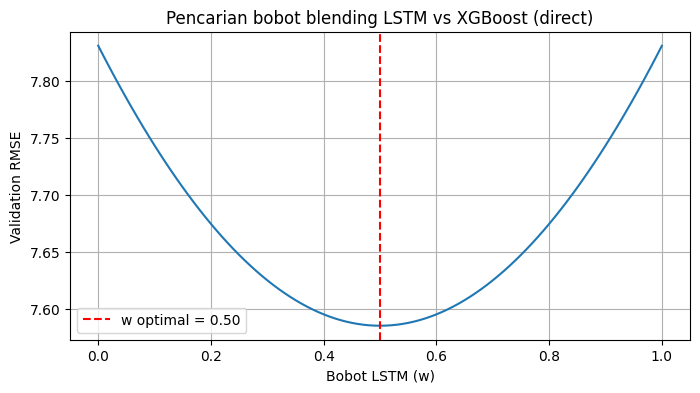

In [10]:
def blended(w, y_lstm, y_xgb):
    return w * y_lstm.ravel() + (1 - w) * y_xgb.ravel()


ws = np.linspace(0, 1, 101)
val_rmses = [
    np.sqrt(mean_squared_error(y_val_true, blended(w, y_val_pred, val_direct_pred)))
    for w in ws
]

best_w = ws[int(np.argmin(val_rmses))]
print(f"Bobot LSTM terbaik (w) berdasarkan validation RMSE: {best_w:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(ws, val_rmses)
plt.axvline(best_w, color="red", linestyle="--", label=f"w optimal = {best_w:.2f}")
plt.xlabel("Bobot LSTM (w)")
plt.ylabel("Validation RMSE")
plt.title("Pencarian bobot blending LSTM vs XGBoost (direct)")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
train_blend_pred = blended(best_w, y_train_pred, train_direct_pred)
val_blend_pred   = blended(best_w, y_val_pred, val_direct_pred)
test_blend_pred  = blended(best_w, y_test_pred, test_direct_pred)

results_summary["blend"] = {
    "train": evaluate(y_train_true, train_blend_pred),
    "val": evaluate(y_val_true, val_blend_pred),
    "test": evaluate(y_test_true, test_blend_pred),
}
results_summary["blend"]


{'train': {'MAE': 3.825141858676798,
  'MSE': 57.7172840636847,
  'RMSE': np.float64(7.597189221263657),
  'NRMSE': np.float64(0.0072839781603678405),
  'R2': 0.9922296016465707},
 'val': {'MAE': 3.724860692705923,
  'MSE': 57.53465660687033,
  'RMSE': np.float64(7.585160288805394),
  'NRMSE': np.float64(0.011510106659795741),
  'R2': 0.9897929268525605},
 'test': {'MAE': 5.374680245159144,
  'MSE': 231.96416152484477,
  'RMSE': np.float64(15.230369710707773),
  'NRMSE': np.float64(0.025990391997794834),
  'R2': 0.881617660464469}}

## Ringkasan perbandingan semua skema

In [12]:
rows = []
for name, m in results_summary.items():
    rows.append({
        "scheme": name,
        "train_MAE": m["train"]["MAE"], "train_R2": m["train"]["R2"],
        "val_MAE": m["val"]["MAE"], "val_RMSE": m["val"]["RMSE"], "val_R2": m["val"]["R2"],
        "test_MAE": m["test"]["MAE"], "test_RMSE": m["test"]["RMSE"], "test_R2": m["test"]["R2"],
    })

summary_df = pd.DataFrame(rows).sort_values("test_RMSE")
summary_df.to_csv("../models/xgb_scheme_comparison.csv", index=False)
summary_df


,scheme,train_MAE,train_R2,val_MAE,val_RMSE,val_R2,test_MAE,test_RMSE,test_R2
3,direct,3.512540,0.993108,3.531763,7.831219,0.989120,5.109953,15.025257,0.884785
4,blend,3.825142,0.992230,3.724861,7.585160,0.989793,5.374680,15.230370,0.881618
0,lstm_only,4.409833,0.990299,4.163210,7.831123,0.989120,5.818821,15.527293,0.876957
1,residual_regularized,4.035689,0.991824,3.847231,7.658378,0.989595,5.443672,15.618283,0.875511
2,residual_optuna,2.755004,0.996890,3.525112,7.516838,0.989976,5.225427,15.759900,0.873243


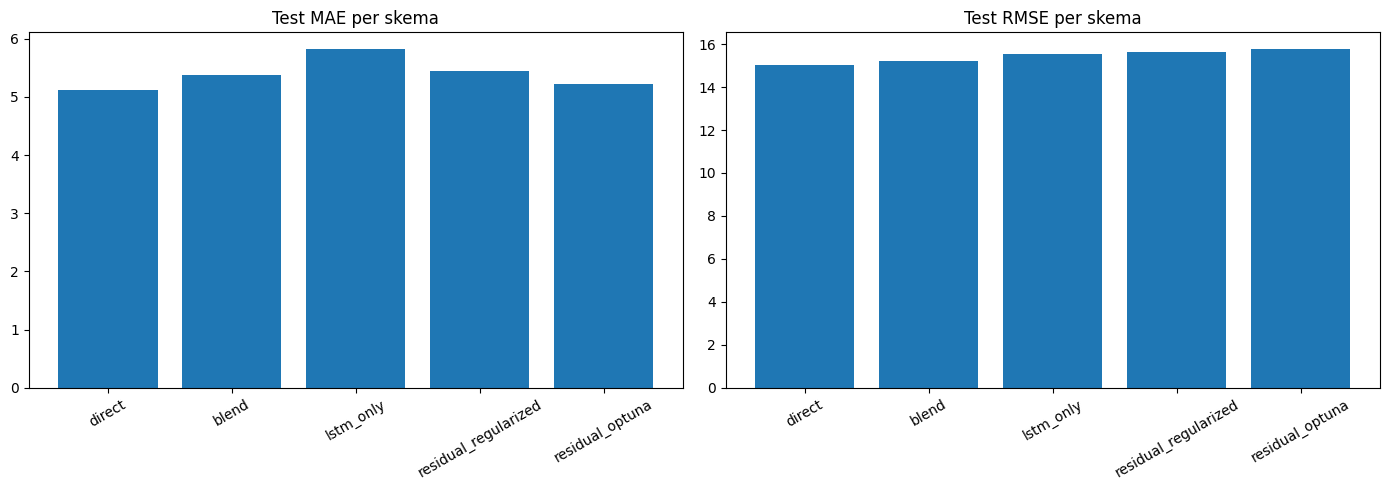

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(summary_df["scheme"], summary_df["test_MAE"])
axes[0].set_title("Test MAE per skema")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(summary_df["scheme"], summary_df["test_RMSE"])
axes[1].set_title("Test RMSE per skema")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## Simpan skema terbaik

In [ ]:
best_scheme = summary_df.iloc[0]["scheme"]
print(f"Skema terbaik (berdasarkan Test RMSE): {best_scheme}")

if best_scheme in ("residual_regularized", "residual_optuna"):
    final_model = xgb_residual_reg if best_scheme == "residual_regularized" else xgb_residual_optuna
    joblib.dump(final_model, "../models/best_xgb.pkl")
    joblib.dump({"scheme": best_scheme, "type": "residual"}, "../models/xgb_scheme_meta.pkl")
elif best_scheme == "direct":
    joblib.dump(xgb_direct, "../models/best_xgb.pkl")
    joblib.dump({"scheme": best_scheme, "type": "direct"}, "../models/xgb_scheme_meta.pkl")
else:  # blend
    joblib.dump(xgb_direct, "../models/best_xgb.pkl")
    joblib.dump({"scheme": best_scheme, "type": "blend", "weight_lstm": float(best_w)}, "../models/xgb_scheme_meta.pkl")

print("Model & metadata skema terbaik tersimpan di ../models/")


Skema terbaik (berdasarkan Test RMSE): direct
Model & metadata skema terbaik tersimpan di ../models/
Bandingkan summary_df di atas dengan hasil notebook 07 asli (LSTM+XGB Test MAE=4.89, RMSE=14.66, R2=0.890) untuk melihat perbaikannya.
